In [2]:
import pandas as pd
import numpy as np

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

In [3]:
orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [5]:
customer_orders = (
    orders
    .merge(
        items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
)

In [6]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90


In [7]:
snapshot_date = (
    customer_orders["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

In [8]:
rfm = customer_orders.groupby(
    "customer_id"
).agg({
    "order_purchase_timestamp":
        lambda x: (
            snapshot_date - x.max()
        ).days,

    "order_id":
        "nunique",

    "price":
        "sum"
})

rfm.columns = [
    "recency",
    "frequency",
    "monetary"
]

rfm.head()

,recency,frequency,monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,288,1,89.80
000161a058600d5901f007fab4c27140,410,1,54.90
0001fd6190edaaf884bcaf3d49edf079,548,1,179.99
0002414f95344307404f0ace7a26f1d5,379,1,149.90
000379cdec625522490c315e70c7a9fb,150,1,93.00


In [9]:
rfm.describe()

,recency,frequency,monetary
count,96478.000000,96478.0,96478.000000
mean,240.121364,1.0,137.041586
std,152.836972,0.0,209.045198
min,1.000000,1.0,0.850000
25%,116.000000,1.0,45.900000
50%,221.000000,1.0,86.575000
75%,350.000000,1.0,149.900000
max,714.000000,1.0,13440.000000


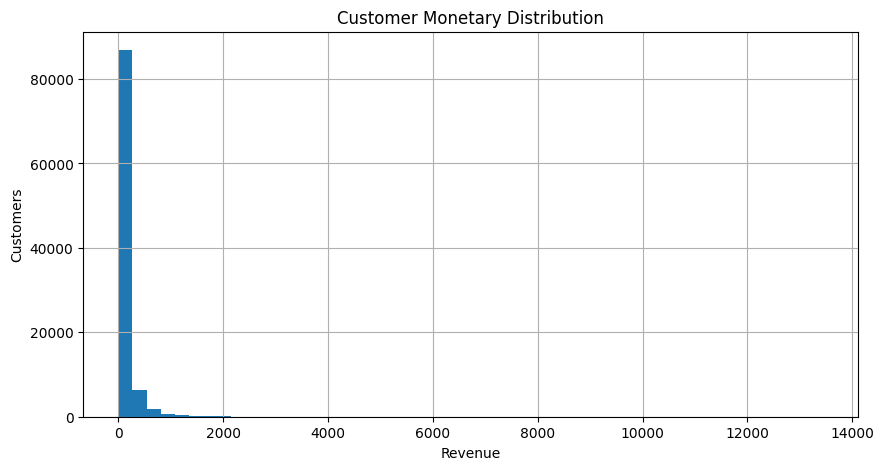

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

rfm["monetary"].hist(
    bins=50
)

plt.title(
    "Customer Monetary Distribution"
)

plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

In [11]:
rfm.describe()

,recency,frequency,monetary
count,96478.000000,96478.0,96478.000000
mean,240.121364,1.0,137.041586
std,152.836972,0.0,209.045198
min,1.000000,1.0,0.850000
25%,116.000000,1.0,45.900000
50%,221.000000,1.0,86.575000
75%,350.000000,1.0,149.900000
max,714.000000,1.0,13440.000000


In [12]:
customer_orders = (
    orders
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        items[
            [
                "order_id",
                "price"
            ]
        ],
        on="order_id",
        how="left"
    )
)

In [13]:
snapshot_date = (
    customer_orders["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

rfm = customer_orders.groupby(
    "customer_unique_id"
).agg({
    "order_purchase_timestamp":
        lambda x: (
            snapshot_date - x.max()
        ).days,

    "order_id":
        "nunique",

    "price":
        "sum"
})

rfm.columns = [
    "recency",
    "frequency",
    "monetary"
]

rfm.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


In [14]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

In [15]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [16]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [17]:
rfm["RFM_Cell"] = (
    rfm["R_score"].astype(str)
    +
    rfm["F_score"].astype(str)
    +
    rfm["M_score"].astype(str)
)

In [18]:
rfm.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_Cell
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215


In [19]:
def assign_segment(cell):

    if cell in [
        "555","554","545","455"
    ]:
        return "VIP Customer"

    elif cell in [
        "111","112","121"
    ]:
        return "At Risk"

    else:
        return "Regular Customer"
    

In [20]:
rfm["segment"] = rfm[
    "RFM_Cell"
].apply(assign_segment)

In [21]:
rfm["segment"].value_counts()

segment
Regular Customer    87535
VIP Customer         3333
At Risk              2490
Name: count, dtype: int64

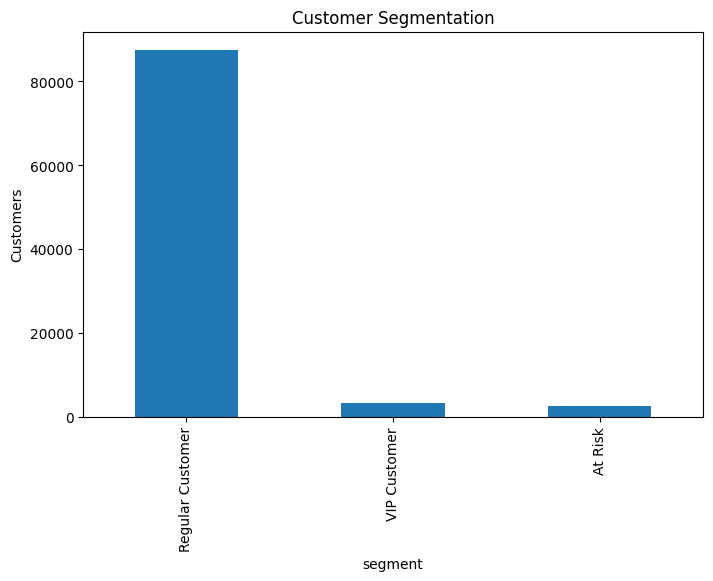

In [22]:
import matplotlib.pyplot as plt

rfm["segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Customer Segmentation"
)

plt.ylabel("Customers")

plt.show()

In [23]:
rfm["segment"].value_counts()

segment
Regular Customer    87535
VIP Customer         3333
At Risk              2490
Name: count, dtype: int64

In [24]:
segment_pct = (
    rfm["segment"]
    .value_counts(normalize=True)
    * 100
)

segment_pct.round(2)

segment
Regular Customer    93.76
VIP Customer         3.57
At Risk              2.67
Name: proportion, dtype: float64

## Customer Intelligence Findings

1. The majority of customers (93.8%) belong to the Regular Customer segment.
2. Only 3.6% of customers are classified as VIP Customers.
3. Approximately 2.7% of customers are categorized as At Risk.
4. A relatively small VIP customer base contributes significant business value and should be prioritized for retention initiatives.
5. At Risk customers represent a potential churn segment and may benefit from targeted engagement campaigns.

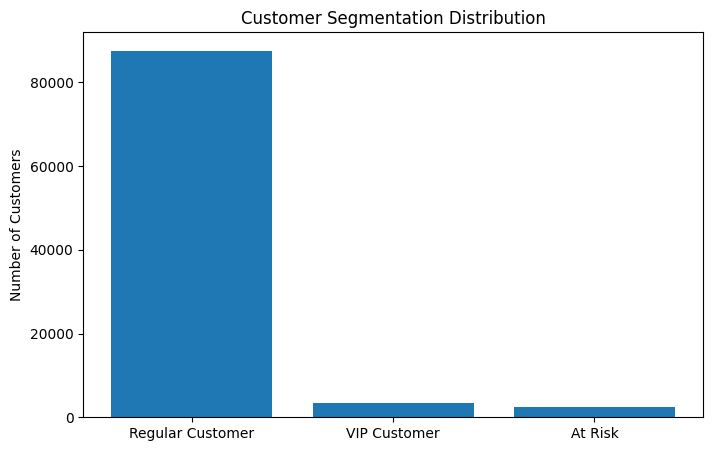

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm["segment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation Distribution")
plt.ylabel("Number of Customers")

plt.show()

In [29]:
segment_avg_revenue = (
    rfm
    .groupby("segment")
    ["monetary"]
    .mean()
    .sort_values(ascending=False)
)

segment_avg_revenue

segment
VIP Customer        346.674926
Regular Customer    136.829228
At Risk              35.616112
Name: monetary, dtype: float64

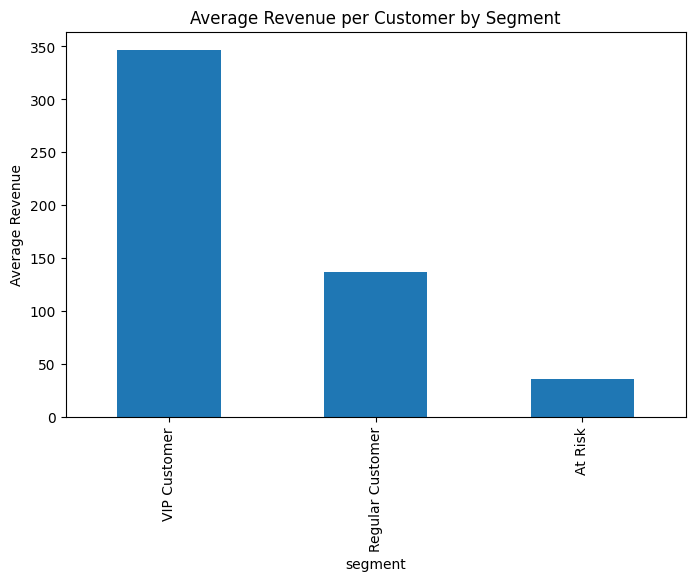

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_avg_revenue.plot(
    kind="bar"
)

plt.title("Average Revenue per Customer by Segment")
plt.ylabel("Average Revenue")

plt.show()

In [31]:
segment_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers=("segment","count"),
        avg_revenue=("monetary","mean"),
        total_revenue=("monetary","sum"),
        avg_frequency=("frequency","mean")
    )
)

segment_summary

,customers,avg_revenue,total_revenue,avg_frequency
segment,,,,
At Risk,2490,35.616112,88684.12,1.000000
Regular Customer,87535,136.829228,11977346.46,1.024836
VIP Customer,3333,346.674926,1155467.53,1.283828
